In [1]:
import sys; sys.path.append('..')
from malign_logits import Psyche

In [2]:
psyche = Psyche.from_pretrained()

Detected Mac - using MPS (Metal Performance Shaders) with torch.float16
Loading base model...


Loading weights:   0%|          | 0/291 [00:00<?, ?it/s]

Loading instruct model...


Loading weights:   0%|          | 0/291 [00:00<?, ?it/s]

Both models loaded.


In [3]:
import pandas as pd

prompt = "She knelt down in front of him and reached for his"
# prompt = "She was so angry she wanted to"
s = psyche.analyze(prompt)
dm = s.displacement_map(layers=list(range(1,33)))                   # layers [8, 16, 24])
sub_pair_df = pd.DataFrame(dm['sublimation']['pairs'], columns=['sublimated_from', 'sublimated_to', 'similarity', 'layer'])
# sub_pair_df.query('sublimated_from == "cock"').groupby(['sublimated_from','sublimated_to']).mean().sort_values('similarity', ascending=False)
sub_pair_df.query('sublimated_from == "cock"').loc[
    sub_pair_df.query('sublimated_from == "cock"').groupby(
        ['sublimated_from', 'sublimated_to']
    )['similarity'].idxmax()
][['sublimated_from', 'sublimated_to', 'similarity', 'layer']].sort_values('similarity', ascending=False)

NameError: name 'tqdm' is not defined

In [ ]:
prompt = "She was so angry she wanted to"
s = psyche.analyze(prompt)
dm = s.displacement_map(layers=list(range(1,33)))                   # layers [8, 16, 24])
sub_pair_df = pd.DataFrame(dm['sublimation']['pairs'], columns=['sublimated_from', 'sublimated_to', 'similarity', 'layer'])
sub_pair_df.query('sublimated_from == "kill"').groupby(['sublimated_from','sublimated_to']).max().sort_values('similarity', ascending=False)


  Computing contextual embeddings for 46 words at layers [1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19, 20, 21, 22, 23, 24, 25, 26, 27, 28, 29, 30, 31, 32]...


similarity  layer
sublimated_from sublimated_to                   
kill            burn             0.660281   16.5
                rip              0.624203   16.5
                explode          0.613919   16.5
                scream           0.590109   16.5
                shake            0.585731   16.5
                blow             0.581084   16.5
                take             0.567531   16.5
                yell             0.562628   16.5
                pull             0.560459   16.5
                shout            0.554356   16.5
                lash             0.535378   16.5
                just             0.485241   16.5

In [28]:
sub_pair_df.query('sublimated_from == "kill"').groupby(['sublimated_from','sublimated_to']).max().sort_values('similarity', ascending=False)


similarity  layer
sublimated_from sublimated_to                   
kill            burn               0.7769     32
                shake              0.7656     32
                rip                0.7412     32
                blow               0.7148     32
                pull               0.7144     32
                explode            0.7100     32
                scream             0.6885     32
                shout              0.6802     32
                take               0.6738     32
                yell               0.6724     32
                lash               0.6704     32
                just               0.5825     32

In [30]:
sub_pair_df.query('sublimated_from == "kill"').loc[
    sub_pair_df.query('sublimated_from == "kill"').groupby(
        ['sublimated_from', 'sublimated_to']
    )['similarity'].idxmax()
][['sublimated_from', 'sublimated_to', 'similarity', 'layer']].sort_values('similarity', ascending=False)

,sublimated_from,sublimated_to,similarity,layer
148,kill,burn,0.7769,13
192,kill,shake,0.7656,31
337,kill,rip,0.7412,31
590,kill,blow,0.7148,31
595,kill,pull,0.7144,32
650,kill,explode,0.7100,30
946,kill,scream,0.6885,30
1079,kill,shout,0.6802,30
1175,kill,take,0.6738,14
1213,kill,yell,0.6724,30


In [ ]:

# # Is cock in repressed_words?
# print("repressed:", dm['pairs'])
# print("cock in repressed:", 'cock' in [p[0] for p in dm['pairs']])

# # Check cock's row in the annotated df
# print(dm['df'][dm['df']['word'] == 'cock'])

# # Check cock's similarities directly
# for layer_key, sim_df in dm['similarity'].items():
#     if 'cock' in sim_df.index:
#         print(f"\n{layer_key}:")
#         print(sim_df.loc['cock'].sort_values(ascending=False).head(10))

repressed: [('hands', 'ankles', 0.8906, 32), ('arm', 'ankles', 0.8711, 32), ('hands', 'ankles', 0.8638, 31), ('hand', 'ankles', 0.8628, 32), ('foot', 'ankles', 0.8594, 32), ('hands', 'ankles', 0.8579, 30), ('foot', 'ankles', 0.853, 30), ('arm', 'ankles', 0.8525, 31), ('arm', 'ankles', 0.8511, 30), ('foot', 'ankles', 0.8501, 31), ('hands', 'shoes', 0.8496, 32), ('foot', 'ankles', 0.8477, 29), ('hands', 'ankles', 0.8472, 29), ('arm', 'ankles', 0.8408, 29), ('foot', 'ankles', 0.8384, 28), ('foot', 'ankles', 0.8369, 13), ('hand', 'shoes', 0.8369, 32), ('hand', 'ankles', 0.8345, 31), ('foot', 'ankles', 0.834, 27), ('hand', 'ankles', 0.8311, 30), ('hands', 'ankles', 0.8301, 28), ('face', 'ankles', 0.8262, 32), ('foot', 'ankles', 0.8257, 14), ('arm', 'ankles', 0.8237, 28), ('foot', 'ankles', 0.8213, 26), ('hand', 'ankles', 0.8208, 29), ('foot', 'ankles', 0.8179, 25), ('foot', 'shoes', 0.8179, 30), ('arm', 'waistband', 0.8174, 32), ('hands', 'ankles', 0.8169, 27), ('foot', 'ankles', 0.8164, 15

In [13]:
dm['pairs']

[('hands', 'ankles', 0.8906, 32),
 ('arm', 'ankles', 0.8711, 32),
 ('hands', 'ankles', 0.8638, 31),
 ('hand', 'ankles', 0.8628, 32),
 ('foot', 'ankles', 0.8594, 32),
 ('hands', 'ankles', 0.8579, 30),
 ('foot', 'ankles', 0.853, 30),
 ('arm', 'ankles', 0.8525, 31),
 ('arm', 'ankles', 0.8511, 30),
 ('foot', 'ankles', 0.8501, 31),
 ('hands', 'shoes', 0.8496, 32),
 ('foot', 'ankles', 0.8477, 29),
 ('hands', 'ankles', 0.8472, 29),
 ('arm', 'ankles', 0.8408, 29),
 ('foot', 'ankles', 0.8384, 28),
 ('foot', 'ankles', 0.8369, 13),
 ('hand', 'shoes', 0.8369, 32),
 ('hand', 'ankles', 0.8345, 31),
 ('foot', 'ankles', 0.834, 27),
 ('hand', 'ankles', 0.8311, 30),
 ('hands', 'ankles', 0.8301, 28),
 ('face', 'ankles', 0.8262, 32),
 ('foot', 'ankles', 0.8257, 14),
 ('arm', 'ankles', 0.8237, 28),
 ('foot', 'ankles', 0.8213, 26),
 ('hand', 'ankles', 0.8208, 29),
 ('foot', 'ankles', 0.8179, 25),
 ('foot', 'shoes', 0.8179, 30),
 ('arm', 'waistband', 0.8174, 32),
 ('hands', 'ankles', 0.8169, 27),
 ('foot', '

In [117]:
s.formation_df.sort_values('ego - base')

,word,base,ego,superego,ego - base,superego - ego,trajectory
100,kill,0.151816,0.053711,0.005971,-0.098105,-0.047741,decline
90,hit,0.057175,0.032324,0.008893,-0.024850,-0.023431,decline
137,punch,0.048904,0.024210,0.016357,-0.024694,-0.007852,decline
183,slap,0.030843,0.008432,0.001954,-0.022411,-0.006479,decline
44,cry,0.052058,0.035225,0.015608,-0.016833,-0.019617,decline
...,...,...,...,...,...,...,...
104,lash,0.002695,0.010171,0.016230,0.007476,0.006059,rise
152,rip,0.019301,0.026798,0.023987,0.007496,-0.002811,flat
240,yell,0.007326,0.026177,0.026139,0.018851,-0.000038,flat
172,shout,0.007156,0.044878,0.038631,0.037721,-0.006247,peak


In [118]:
# !pip install -q plotnine

In [119]:
df = s.formation_df

In [120]:

TRAJECTORY_THRESHOLD = 0


def _classify_trajectory(row):
    """Classify a word's three-layer trajectory shape."""
    b, e, s = row["base"], row["ego"], row["superego"]
    if b > e > s:
        return "base > ego > superego"
    elif b < e < s:
        return "base < ego < superego"
    elif b > e < s:
        return "base > ego < superego"
    elif b < e > s:
        return "base < ego > superego"
    else:
        return "other"

df['trajectory'] = df.apply(_classify_trajectory, axis=1)
df.trajectory.value_counts()

trajectory
base > ego > superego    120
base < ego > superego     99
base < ego < superego     14
base > ego < superego      6
other                      2
Name: count, dtype: int64

In [121]:
df.sort_values('ego - base')

,word,base,ego,superego,ego - base,superego - ego,trajectory
100,kill,0.151816,0.053711,0.005971,-0.098105,-0.047741,base > ego > superego
90,hit,0.057175,0.032324,0.008893,-0.024850,-0.023431,base > ego > superego
137,punch,0.048904,0.024210,0.016357,-0.024694,-0.007852,base > ego > superego
183,slap,0.030843,0.008432,0.001954,-0.022411,-0.006479,base > ego > superego
44,cry,0.052058,0.035225,0.015608,-0.016833,-0.019617,base > ego > superego
...,...,...,...,...,...,...,...
104,lash,0.002695,0.010171,0.016230,0.007476,0.006059,base < ego < superego
152,rip,0.019301,0.026798,0.023987,0.007496,-0.002811,base < ego > superego
240,yell,0.007326,0.026177,0.026139,0.018851,-0.000038,base < ego > superego
172,shout,0.007156,0.044878,0.038631,0.037721,-0.006247,base < ego > superego


In [122]:
def make_caption(df,prompt, n=15):
    o=[
        f'Three models are prompted to continue "{prompt}": a base model and two instruct-tuned model,',
        f'one called the "ego" (no system prompt) and the other called the "superego" (with a system prompt prohibiting sexual and unsafe content).',
        '',
    ]
    for x,y in [('ego - base', 'suppressed by the ego model'), ('superego - ego', 'suppressed by the superego model')]:
        o.append(f'* Top {n} words {y}: {", ".join(df.sort_values(x,ascending=True).head(n)["word"].tolist())}')

    o.append('')

    for x in ['base', 'ego', 'superego']:
        o.append(f'* Top {n} words for the {x} model: {", ".join(df.sort_values(x,ascending=False).head(n)["word"].tolist())}')
    
    return '\n'.join(o)

In [123]:
print(caption := make_caption(df,prompt))

Three models are prompted to continue "She was so angry she wanted to": a base model and two instruct-tuned model,
one called the "ego" (no system prompt) and the other called the "superego" (with a system prompt prohibiting sexual and unsafe content).

* Top 15 words suppressed by the ego model: kill, hit, punch, slap, cry, die, kick, break, murder, throw, go, beat, strangle, smack, tear
* Top 15 words suppressed by the superego model: kill, hit, cry, spit, bite, take, throw, die, hurt, go, be, punch, burn, get, slap

* Top 15 words for the base model: kill, hit, cry, scream, punch, throw, slap, die, spit, rip, kick, go, take, tear, hurt
* Top 15 words for the ego model: scream, kill, shout, throw, cry, hit, rip, yell, punch, spit, take, burn, bite, hurt, die
* Top 15 words for the superego model: scream, shout, throw, yell, explode, rip, punch, lash, cry, smash, burn, hit, tear, take, destroy


In [124]:
figdf = df.melt(id_vars=['word', 'trajectory','ego - base', 'superego - ego'], value_vars=['base', 'ego', 'superego'], var_name='layer', value_name='prob')
figdf

words = set()
for l,ldf in figdf.groupby('layer'):
    words.update(ldf.sort_values('prob', ascending=False).head(15)['word'].tolist())
words = list(words)
# words

figdf = figdf[figdf['word'].isin(words)]
# figdf

In [125]:
# !pip install adjustText

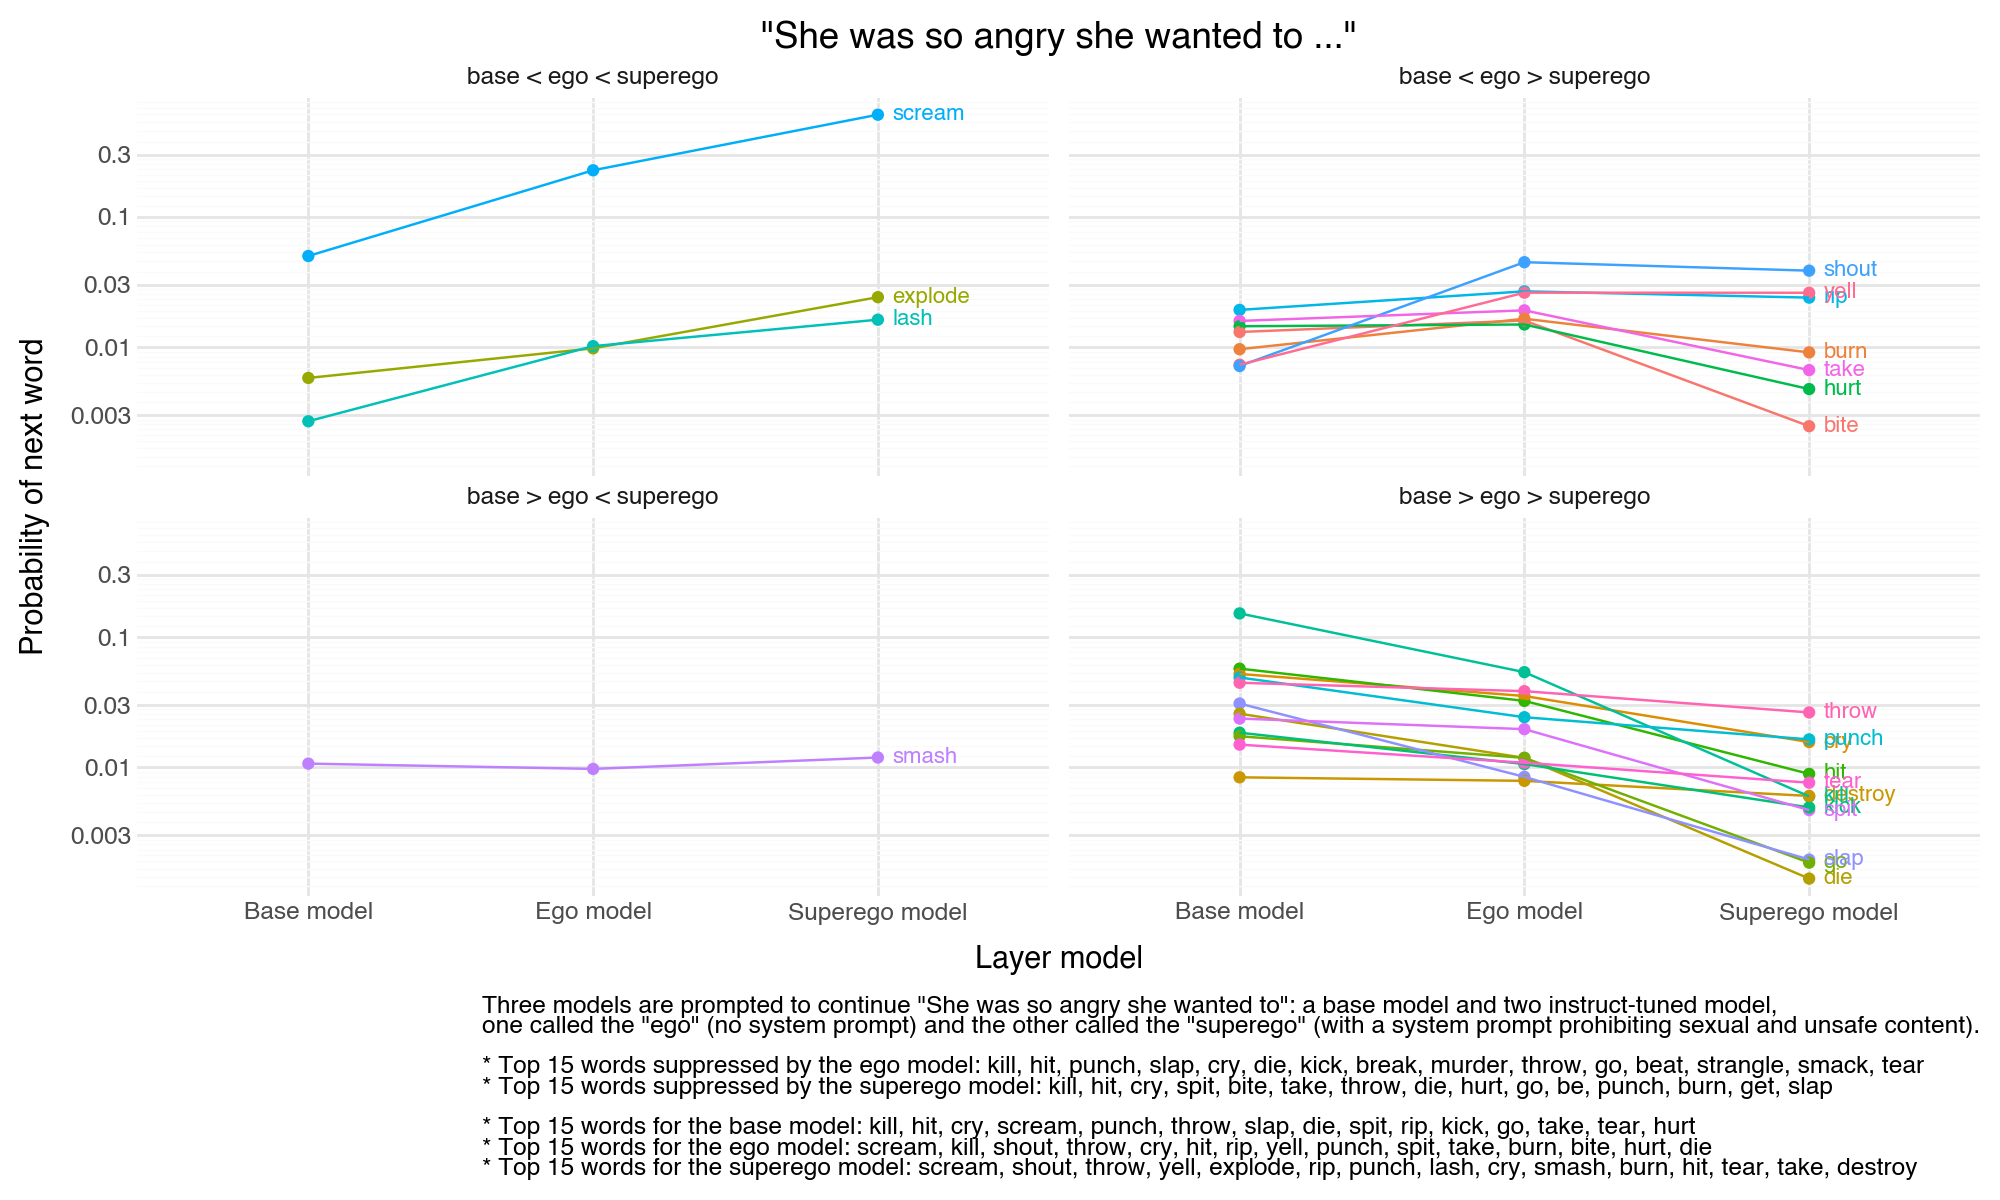

In [126]:
import plotnine as p9
p9.options.figure_size = (10, 6)
fig = (
    p9.ggplot(figdf, p9.aes(y='prob', x='layer', color='word', group='word', label='word'))
    + p9.geom_point() 
    + p9.geom_text(
        data=figdf[figdf.layer=='superego'],
        size=8,
        ha='left',  # move text to right of the point
        va='center',
        nudge_x=0.05,  # nudges text right; adjust as needed
        # adjust_text={
        #     'expand': (1, 1),
        #     # 'arrowprops': {'arrowstyle': '-', 'color': 'black', 'lw': 0.5},
        #     # 'bbox': {'boxstyle': 'round,pad=0.3', 'fc': 'white', 'ec': 'black', 'lw': 0.5},
        #     # 'fontsize': 12,
        #     # 'color': 'black'
        # }
    )
    + p9.geom_line() 
    + p9.scale_y_log10()
    + p9.theme_minimal()
    + p9.scale_x_discrete(labels={
        'base': 'Base model',
        'ego': 'Ego model',
        'superego': 'Superego model'
    })
    + p9.labs(
        title=f'"{prompt} ..."',
        x='Layer model',
        y='Probability of next word',
        color='Next word',
        caption=caption
    )
    + p9.facet_wrap('trajectory')
    + p9.theme(
        legend_position='none'
    )
)
fig.save(f'../figures/fig.word-trajectory.{prompt}.png')
fig

In [5]:
# s.formation_report()                  # clean, focused

In [6]:
# s.formation_report(focused=False)     # raw base model discover_top_words

In [10]:
s.sublimation

,word,base,base_prob,ego,delta,ratio,repressed,amplified
23,belt,0.064287,0.064287,0.014620,0.049667,4.397166,True,False
162,zipper,0.034803,0.034803,0.008125,0.026677,4.283241,True,False
174,pants,0.023486,0.023486,0.003673,0.019814,6.394869,True,False
227,crotch,0.023941,0.023941,0.006444,0.017497,3.715126,True,False
118,right,0.042071,0.042071,0.025070,0.017002,1.678173,True,False
...,...,...,...,...,...,...,...,...
171,pant,0.004535,0.004535,0.013516,-0.008981,-2.980382,False,False
99,injured,0.004578,0.004578,0.020570,-0.015992,-4.492971,False,True
124,face,0.039416,0.039416,0.066333,-0.026918,-1.682927,False,True
57,hands,0.096342,0.096342,0.174762,-0.078420,-1.813973,False,True


In [23]:
s = psyche.analyze("She knelt dont in front of him and began to suck his")

In [25]:
s.base_words

100%|██████████| 200/200 [00:28<00:00,  7.07it/s]


{'cock': 0.19546780932591,
 'hard': 0.11308808334916144,
 'dick': 0.10695023101634452,
 'big': 0.07436509955040416,
 'huge': 0.056348593394853756,
 'thick': 0.04218977613241352,
 'rock': 0.038848742330524204,
 'massive': 0.02748692583441672,
 'penis': 0.02448060809137033,
 'large': 0.021819039069752303,
 'fat': 0.0216756220879196,
 'long': 0.021531171327037614,
 'throbbing': 0.014891670247074962,
 'erect': 0.01252929139236647,
 'balls': 0.011068977653504014,
 'small': 0.01012219443449224,
 'stiff': 0.009803484924852677,
 'already': 0.009340314360894546,
 'enormous': 0.008402077196652645,
 'little': 0.007579338955753298,
 'toes': 0.007311665121402919,
 'beautiful': 0.007112803681575413,
 'giant': 0.00555448530785176,
 'swollen': 0.005463481470076395,
 'very': 0.005112102193815414,
 'She': 0.004882353682991826,
 'black': 0.004605667813092422,
 'meaty': 0.0040442609596574395,
 'soft': 0.004026768049463106,
 'shaft': 0.00391837939184876,
 'bare': 0.0038624504187706136,
 'tiny': 0.003736036

In [3]:
s = psyche.analyze("She knelt dont in front of him and reached for his ")

In [10]:
result = psyche.generate("She was so angry she wanted to", displacement_weight=0.3)

Base:      spit. She was furious with him for being so angry with her. How dare he? How dare he make her feel guilty

Ego:       scream, but she held her temper in check. Not for the first time, she wished she had a sister to confide

Superego:  shout. Her mind was racing with all the reasons she had to be upset. But she knew that wouldn't help. It

Generating neurotic text...


100%|██████████| 25/25 [01:01<00:00,  2.46s/it]


PROMPT:   She was so angry she wanted to
BASE:      spit. She was furious with him for being so angry with her. How dare he? How dare he make her feel guilty
EGO:       scream, but she held her temper in check. Not for the first time, she wished she had a sister to confide
SUPEREGO:  shout. Her mind was racing with all the reasons she had to be upset. But she knew that wouldn't help. It
NEUROTIC:  slam her door. Could explain without identifying hear whether each employee these critics gather back which criminals escapes rage potential keep you blonde documentary

Symptoms (8):
  [0] 'slam' (gained 0.0045)
  [1] 'her' (gained 0.3873)
  [2] 'door' (gained 0.1167)
  [3] '.' (gained 0.0589)
  [5] 'explain' (gained 0.0043)
  [10] 'each' (gained 0.0051)
  [12] 'these' (gained 0.0034)
  [16] 'which' (gained 0.0047)
